<a href="https://colab.research.google.com/github/brigithsuarez-oss/TAREA-1/blob/main/TAREA_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TAREA 1**

Objetivo

Realizar la adquisición de una API de datos meteorológicos y visualizar los datos.

Plantear y contestar preguntas sobre los datos

**Proceso**


1.   Revisar el API y variables que me ofrece
2.   Escojo la ubicación para el análisis de las variables y genero preguntas que quiero responder


1.   Seleccionar las variable para la ubicación
2.   Copio y pego el código otorgado por el programa metereologico.


1.   A partir de ahí realizo análisis descriptivo de las variables con el fin de comprender su comportamiento
2.   Elaboro los gráficos


1.   Realizo el analisis de los graficos
2.   Presentación en GitHub







Copio el codigo de la API https://open-meteo.com/


**PROCESO **

1. Se realizo la revisión de la API y variables

2. Ubicación a analizar:
Latitud -0,4363, Longitud -76,9943
Francisco de Orellana

PREGUNTAS A RELIZAR

1.¿Qué hora es más frecuente que exista precipitación en Francisco de Orellana?

2. ¿Cuál es el dia con el Indice UV más Alto y que temperatura tenia?

3. ¿Qué relación existe entre la temperatura y la probabilidad de precipitación?

Variables a utilizar de los ultimos 16 dias:

VARIABLES METEREOLOGICAS POR HORA
- Temperatura 2m
- Probabilidad de precipitación
- Ráfagas de viento (10 m)
- Temperatura del suelo (6 cm)
VARIABLES METEREOLOGICAS DIARIAS
- Temperatura máxima (2 m)
- Temperatura mínima (2 m)
- Índice UV
- Índice UV Cielo despejado


In [5]:
!pip install openmeteo-requests
!pip install requests-cache retry-requests numpy pandas

In [4]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://api.open-meteo.com/v1/forecast"
params = {
	"latitude": -0.4363,
	"longitude": -76.9943,
	"daily": ["temperature_2m_max", "temperature_2m_min", "uv_index_max", "uv_index_clear_sky_max"],
	"hourly": ["temperature_2m", "precipitation_probability", "wind_gusts_10m", "soil_temperature_6cm"],
	"current": ["rain", "temperature_2m"],
	"forecast_days": 14,
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process current data. The order of variables needs to be the same as requested.
current = response.Current()
current_rain = current.Variables(0).Value()
current_temperature_2m = current.Variables(1).Value()

print(f"\nCurrent time: {current.Time()}")
print(f"Current rain: {current_rain}")
print(f"Current temperature_2m: {current_temperature_2m}")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_precipitation_probability = hourly.Variables(1).ValuesAsNumpy()
hourly_wind_gusts_10m = hourly.Variables(2).ValuesAsNumpy()
hourly_soil_temperature_6cm = hourly.Variables(3).ValuesAsNumpy()

hourly_data = {
	"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	)
}

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["precipitation_probability"] = hourly_precipitation_probability
hourly_data["wind_gusts_10m"] = hourly_wind_gusts_10m
hourly_data["soil_temperature_6cm"] = hourly_soil_temperature_6cm

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_temperature_2m_max = daily.Variables(0).ValuesAsNumpy()
daily_temperature_2m_min = daily.Variables(1).ValuesAsNumpy()
daily_uv_index_max = daily.Variables(2).ValuesAsNumpy()
daily_uv_index_clear_sky_max = daily.Variables(3).ValuesAsNumpy()

daily_data = {
	"date": pd.date_range(
		start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = daily.Interval()),
		inclusive = "left"
	)
}

daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["temperature_2m_min"] = daily_temperature_2m_min
daily_data["uv_index_max"] = daily_uv_index_max
daily_data["uv_index_clear_sky_max"] = daily_uv_index_clear_sky_max

daily_dataframe = pd.DataFrame(data = daily_data)
print("\nDaily data\n", daily_dataframe)


Coordinates: -0.45694199204444885°N -76.97183227539062°E
Elevation: 256.0 m asl
Timezone difference to GMT+0: 0s

Current time: 1790433900
Current rain: 0.0
Current temperature_2m: 27.649999618530273

Hourly data
                          date  temperature_2m  precipitation_probability  \
0   2026-09-26 00:00:00+00:00       24.850000                       55.0   
1   2026-09-26 01:00:00+00:00       24.150000                       65.0   
2   2026-09-26 02:00:00+00:00       23.650000                       82.0   
3   2026-09-26 03:00:00+00:00       23.150000                       86.0   
4   2026-09-26 04:00:00+00:00       23.000000                       63.0   
..                        ...             ...                        ...   
331 2026-10-09 19:00:00+00:00       25.950001                       76.0   
332 2026-10-09 20:00:00+00:00       25.850000                       77.0   
333 2026-10-09 21:00:00+00:00       25.650000                       78.0   
334 2026-10-09 22:00:00+00

5. A partir de ahí realizo análisis descriptivo de las variables con el fin de comprender su comportamiento

In [6]:
import pandas as pd

# Generar el resumen estadístico descriptivo para daily_dataframe
display(daily_dataframe.describe())

,temperature_2m_max,temperature_2m_min,uv_index_max,uv_index_clear_sky_max
count,14.000000,14.000000,14.000000,14.000000
mean,30.035717,23.207144,7.403571,9.232142
std,1.800793,0.665599,2.256398,0.037247
min,26.299999,22.150000,1.050000,9.150000
25%,29.925000,22.750000,6.625000,9.200000
50%,30.200001,23.100000,7.525000,9.250000
75%,31.337500,23.625000,9.175000,9.250000
max,32.049999,24.750000,9.350000,9.300000


1. ¿Qué hora es más frecuente que exista precipitación en Francisco de Orellana?

In [7]:
# Extraer la hora del día de la columna 'date'
hourly_dataframe['hour'] = hourly_dataframe['date'].dt.hour

# Filtrar las horas con probabilidad de precipitación (ej. > 0)
precipitation_hours = hourly_dataframe[hourly_dataframe['precipitation_probability'] > 0]

# Contar la frecuencia de cada hora
hourly_precipitation_counts = precipitation_hours['hour'].value_counts()

# Obtener la hora más frecuente
most_frequent_hour = hourly_precipitation_counts.idxmax()
most_frequent_count = hourly_precipitation_counts.max()

print(f"La hora más frecuente con probabilidad de precipitación en los últimos 16 días es las {most_frequent_hour}:00 con {most_frequent_count} ocurrencias.")

La hora más frecuente con probabilidad de precipitación en los últimos 16 días es las 0:00 con 14 ocurrencias.


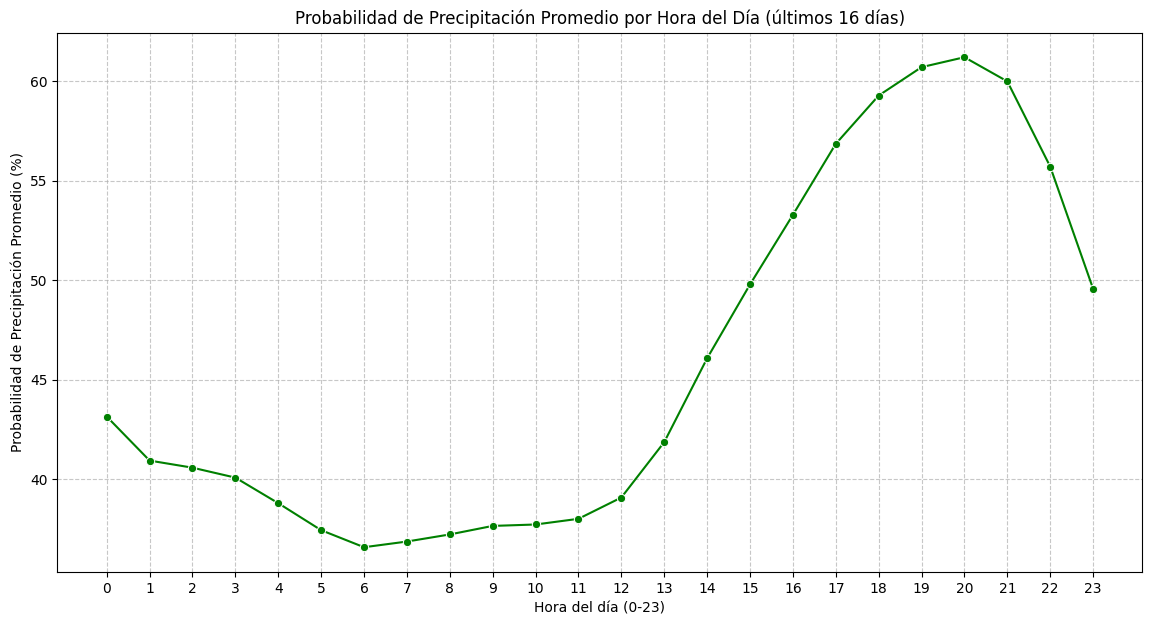

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular la probabilidad de precipitación promedio por hora del día
average_hourly_precipitation = hourly_dataframe.groupby('hour')['precipitation_probability'].mean().reset_index()

# Crear el gráfico de líneas
plt.figure(figsize=(14, 7))
sns.lineplot(x='hour', y='precipitation_probability', data=average_hourly_precipitation, marker='o', color='green')

# Añadir etiquetas y título
plt.xlabel('Hora del día (0-23)')
plt.ylabel('Probabilidad de Precipitación Promedio (%)')
plt.title('Probabilidad de Precipitación Promedio por Hora del Día (últimos 16 días)')
plt.xticks(range(24)) # Asegurar que todas las horas se muestren en el eje X
plt.grid(True, linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.show()

Existe una probabilidad mayor de que llueva en las noches con un pico maximo a las 8 de la noche en los últimos 16 días

2. ¿Cuál es el dia con el Indice UV más Alto y que temperatura tenia?

In [14]:
import pandas as pd

# Encontrar el día con el índice UV máximo
highest_uv_day = daily_dataframe.loc[daily_dataframe['uv_index_max'].idxmax()]

# Mostrar el resultado
print(f"El día con el Índice UV más alto es: {highest_uv_day['date'].strftime('%Y-%m-%d')}")
print(f"Índice UV Máximo: {highest_uv_day['uv_index_max']}")
print(f"Temperatura Máxima ese día: {highest_uv_day['temperature_2m_max']} °C")
print(f"Temperatura Mínima ese día: {highest_uv_day['temperature_2m_min']} °C")

El día con el Índice UV más alto es: 2026-10-01
Índice UV Máximo: 9.350000381469727
Temperatura Máxima ese día: 29.899999618530273 °C
Temperatura Mínima ese día: 23.850000381469727 °C


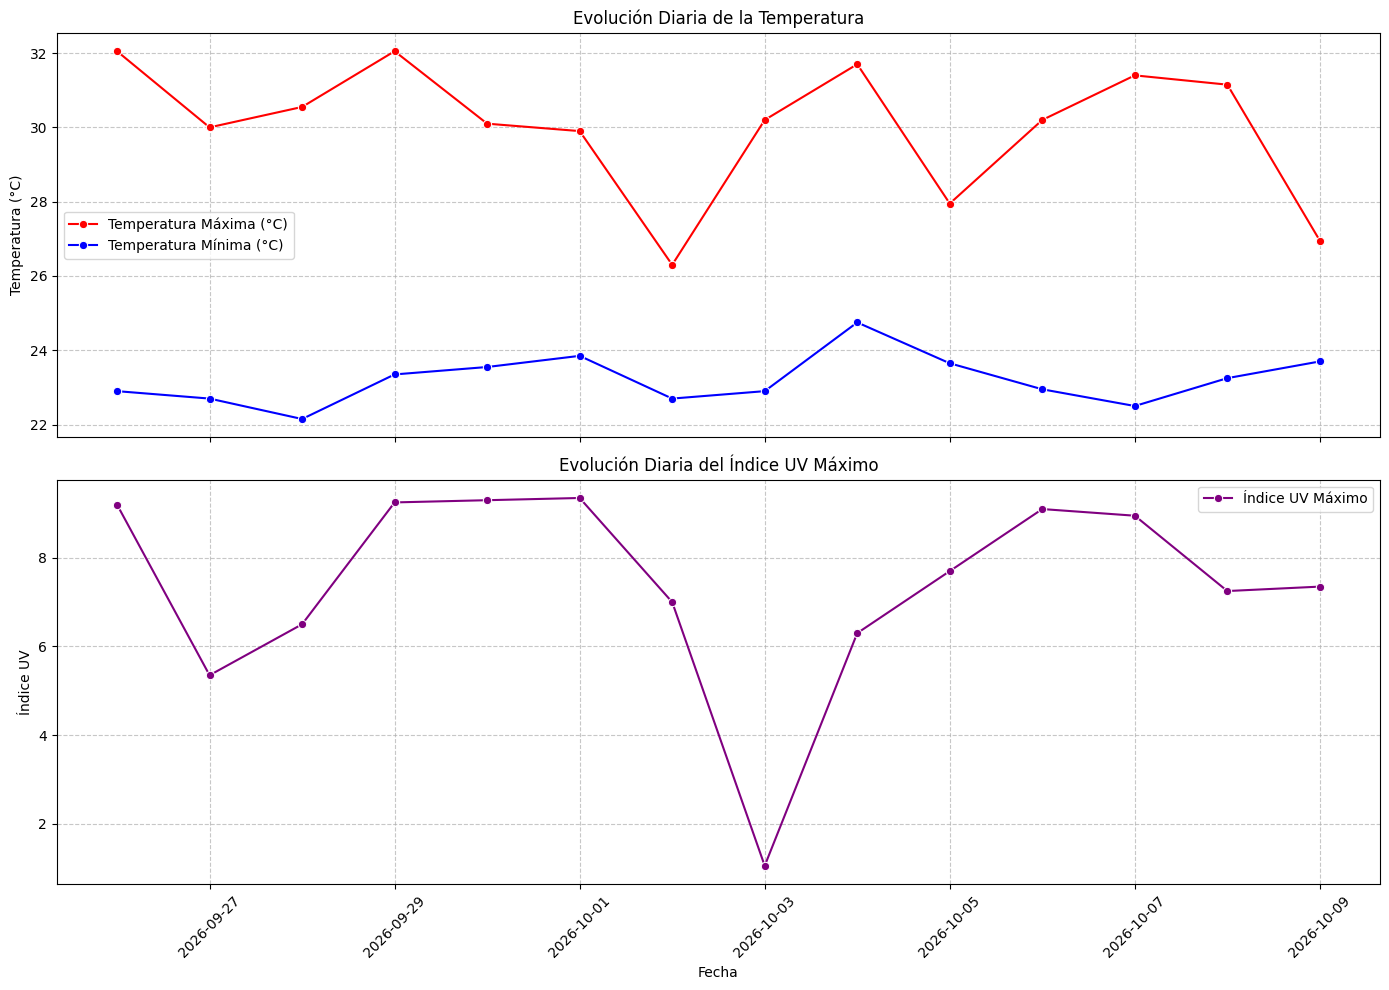

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear la figura y los subgráficos
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True)

# Subgráfico 1: Evolución diaria de la temperatura máxima y mínima
sns.lineplot(ax=axes[0], x='date', y='temperature_2m_max', data=daily_dataframe, marker='o', label='Temperatura Máxima (°C)', color='red')
sns.lineplot(ax=axes[0], x='date', y='temperature_2m_min', data=daily_dataframe, marker='o', label='Temperatura Mínima (°C)', color='blue')
axes[0].set_title('Evolución Diaria de la Temperatura')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# Subgráfico 2: Evolución diaria del Índice UV Máximo
sns.lineplot(ax=axes[1], x='date', y='uv_index_max', data=daily_dataframe, marker='o', label='Índice UV Máximo', color='purple')
axes[1].set_title('Evolución Diaria del Índice UV Máximo')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Índice UV')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

# Formatear las fechas en el eje x para una mejor lectura
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
import pandas as pd

# Calcular la correlación entre el Índice UV máximo y la temperatura máxima
correlation = daily_dataframe['uv_index_max'].corr(daily_dataframe['temperature_2m_max'])

print(f"La correlación entre el Índice UV Máximo y la Temperatura Máxima es: {correlation:.2f}")

La correlación entre el Índice UV Máximo y la Temperatura Máxima es: 0.14


Este valor indica una correlación positiva muy baja, lo que sugiere que, si bien hay una leve tendencia a que el Índice UV máximo aumente con la temperatura máxima, esta relación no es fuerte en los datos proporcionados.

3. ¿Qué relación existe entre la temperatura y la probabilidad de precipitación?

In [22]:
correlation_precip_temp = hourly_dataframe['precipitation_probability'].corr(hourly_dataframe['temperature_2m'])
print(f"La correlación entre la probabilidad de precipitación por hora y la temperatura por hora es: {correlation_precip_temp:.2f}")

La correlación entre la probabilidad de precipitación por hora y la temperatura por hora es: 0.16


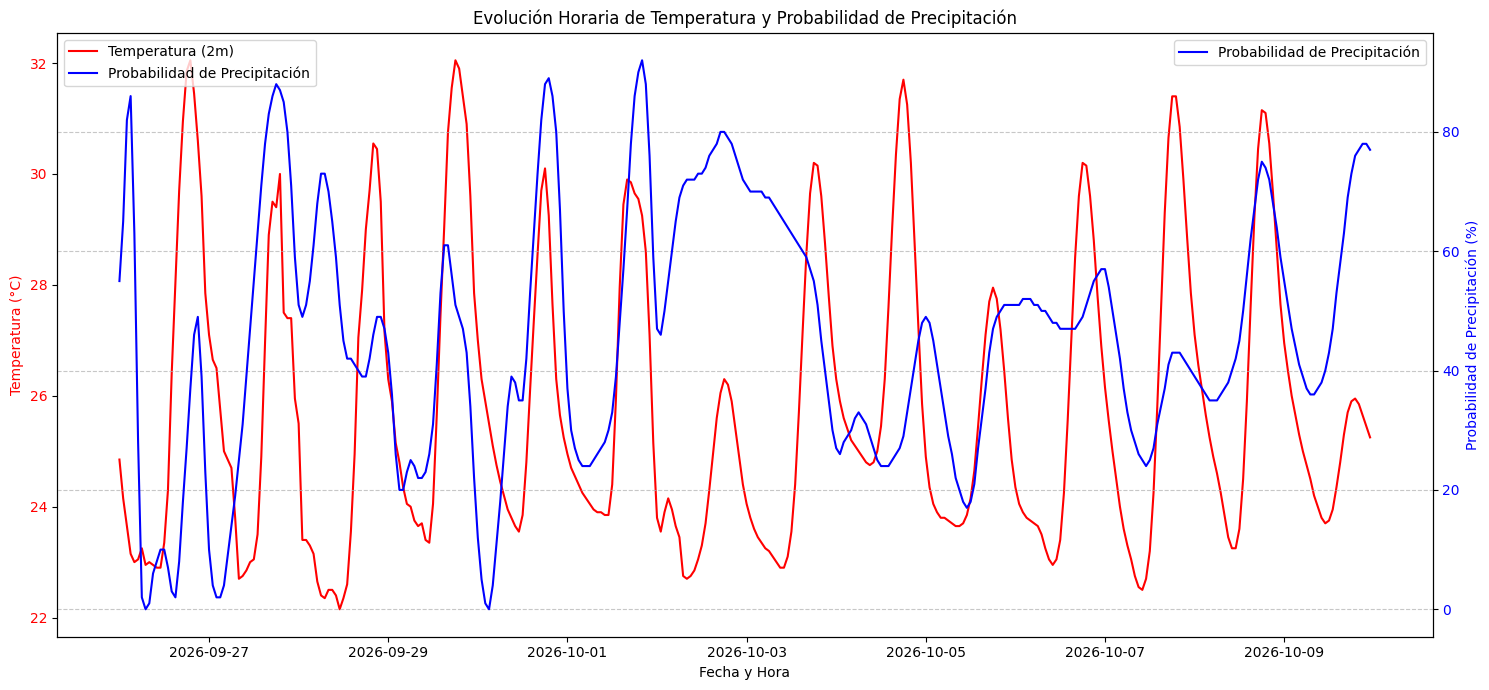

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear la figura y los ejes
fig, ax1 = plt.subplots(figsize=(15, 7))

# Graficar la temperatura en el eje y izquierdo (ax1)
sns.lineplot(x='date', y='temperature_2m', data=hourly_dataframe, ax=ax1, color='red', label='Temperatura (2m)')
ax1.set_xlabel('Fecha y Hora')
ax1.set_ylabel('Temperatura (°C)', color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_title('Evolución Horaria de Temperatura y Probabilidad de Precipitación')

# Crear un segundo eje y (ax2) para la probabilidad de precipitación
ax2 = ax1.twinx()
sns.lineplot(x='date', y='precipitation_probability', data=hourly_dataframe, ax=ax2, color='blue', label='Probabilidad de Precipitación')
ax2.set_ylabel('Probabilidad de Precipitación (%)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Mejorar la leyenda combinando las de ambos ejes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

# Rotar las etiquetas del eje X para una mejor lectura
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Al hacer una revisión de las variables de manera gráfica no se evidencia una relación clara, por lo que se requiere un rango mayor de datos, sin embargo, mayormente la probabilidad de precipitación aparece cuando las temperaturas bajan.